<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-failure-prediction/blob/main/Modelling_RNN_and_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import torch.nn as nn
from google.colab import drive
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


In [4]:
X_train_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/X_train_sequential.csv", encoding = "latin1")
y_train_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/y_train_sequential.csv", encoding = "latin1")

X_valid_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/X_valid_sequential.csv", encoding = "latin1")
y_valid_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/y_valid_sequential.csv", encoding = "latin1")

X_test_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/X_test_sequential.csv", encoding = "latin1")
y_test_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/y_test_sequential.csv", encoding = "latin1")


In [5]:
# convert categorical columns

X_train_sequential['Lining'] = X_train_sequential['Lining'].astype("category")
X_train_sequential['Surface'] = X_train_sequential['Surface'].astype("category")
X_train_sequential['Soil'] = X_train_sequential['Soil'].astype("category")
X_train_sequential['Material'] = X_train_sequential['Material'].astype("category")


X_valid_sequential['Lining'] = X_valid_sequential['Lining'].astype("category")
X_valid_sequential['Surface'] = X_valid_sequential['Surface'].astype("category")
X_valid_sequential['Soil'] = X_valid_sequential['Soil'].astype("category")
X_valid_sequential['Material'] = X_valid_sequential['Material'].astype("category")


X_test_sequential['Lining'] = X_test_sequential['Lining'].astype("category")
X_test_sequential['Surface'] = X_test_sequential['Surface'].astype("category")
X_test_sequential['Soil'] = X_test_sequential['Soil'].astype("category")
X_test_sequential['Material'] = X_test_sequential['Material'].astype("category")


In [6]:
# convert to tidy data

X_train_sequential_tidy = pd.get_dummies(X_train_sequential)
X_valid_sequential_tidy = pd.get_dummies(X_valid_sequential)
X_test_sequential_tidy = pd.get_dummies(X_test_sequential)


In [7]:
# normalise data

scaler = StandardScaler()

for feature in X_train_sequential_tidy[["Diameter", "Length", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Age", "Previous bursts"]]:
  X_train_sequential_tidy[feature] = scaler.fit_transform(X_train_sequential_tidy[[feature]])

for feature in X_valid_sequential_tidy[["Diameter", "Length", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Age", "Previous bursts"]]:
  X_valid_sequential_tidy[feature] = scaler.fit_transform(X_valid_sequential_tidy[[feature]])

for feature in X_test_sequential_tidy[["Diameter", "Length", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Age", "Previous bursts"]]:
  X_test_sequential_tidy[feature] = scaler.fit_transform(X_test_sequential_tidy[[feature]])

In [8]:
# filter response vector to contain only result for latest burst

index = X_train_sequential_tidy.groupby("Asset.ID")["Age"].nlargest(1).reset_index(level = 0, drop = True).index
y_train_sequential_tidy = y_train_sequential.loc[index]

index = X_valid_sequential_tidy.groupby("Asset.ID")["Age"].nlargest(1).reset_index(level = 0, drop = True).index
y_valid_sequential_tidy = y_valid_sequential.loc[index]

index = X_test_sequential_tidy.groupby("Asset.ID")["Age"].nlargest(1).reset_index(level = 0, drop = True).index
y_test_sequential_tidy = y_test_sequential.loc[index]

In [114]:
# remove asset ID

# X_train_sequential_tidy = X_train_sequential_tidy.drop("Asset.ID", axis = 1)
# X_test_sequential_tidy = X_test_sequential_tidy.drop("Asset.ID", axis = 1)

In [9]:
# add empty columns for missing categories to the test and valid data (required for model testing and validation)

X_test_sequential_tidy["Material_Steel"] = 0
X_test_sequential_tidy["Material_Steel"] = X_test_sequential_tidy["Material_Steel"].astype(bool)

X_test_sequential_tidy["Lining_PRESENT"] = 0
X_test_sequential_tidy["Lining_PRESENT"] = X_test_sequential_tidy["Lining_PRESENT"].astype(bool)

X_valid_sequential_tidy["Material_Ductile_Iron"] = 0
X_valid_sequential_tidy["Material_Ductile_Iron"] = X_valid_sequential_tidy["Material_Ductile_Iron"].astype(bool)

In [10]:
# convert data frame to numpy array
X_train_numpy = X_train_sequential_tidy.to_numpy(dtype = np.float32)
X_valid_numpy = X_valid_sequential_tidy.to_numpy(dtype = np.float32)
X_test_numpy = X_test_sequential_tidy.to_numpy(dtype = np.float32)

In [11]:
# convert numpy array to tensor

X_train_tensor = tf.convert_to_tensor(X_train_numpy)

X_valid_tensor = tf.convert_to_tensor(X_valid_numpy)

X_test_tensor = tf.convert_to_tensor(X_test_numpy)

In [12]:
# adjust tensor shape

X_train_tensor = tf.reshape(X_train_tensor, (720, 5, 29))

X_valid_tensor = tf.reshape(X_valid_tensor, (29, 5, 29))

X_test_tensor = tf.reshape(X_test_tensor, (44, 5, 29))

# Modelling

In [13]:
from keras import models
from keras import layers


##### RNN

In [20]:
model = models.Sequential([
    layers.SimpleRNN(
        units=256,
        input_shape=(5, 29),
        activation='tanh',
        return_sequences=False
    ),
    layers.Dense(1, activation='relu')
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', "root_mean_squared_error"]
)

model.summary()

# Train
history = model.fit(
    X_train_tensor,
    y_train_sequential_tidy,
    epochs=50,
    batch_size=32,
    validation_data = (X_valid_tensor, y_valid_sequential_tidy)
)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 256)            │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,473 (287.00 KB)

 Trainable params: 73,473 (287.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 12.2572 - mae: 2.0850 - root_mean_squared_error: 3.5010 - val_loss: 0.3109 - val_mae: 0.3483 - val_root_mean_squared_error: 0.5576
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.2572 - mae: 2.0850 - root_mean_squared_error: 3.5010 - val_loss: 0.3109 - val_mae: 0.3483 - val_root_mean_squared_error: 0.5576
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.2572 - mae: 2.0850 - root_mean_squared_error: 3.5010 - val_loss: 0.3109 - val_mae: 0.3483 - val_root_mean_squared_error: 0.5576
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.2572 - mae: 2.0850 - root_mean_squared_error: 3.5010 - val_loss: 0.3109 - val_mae: 0.3483 - val_root_mean_squared_error: 0.5576
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 12.2572 - mae: 2.0850 - root_mean_squared_error: 3.5010 - val_loss: 0.3109 - val_mae: 0.3483 - val_root_mean_squared_error: 0.5576
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Text(0, 0.5, 'MAE')

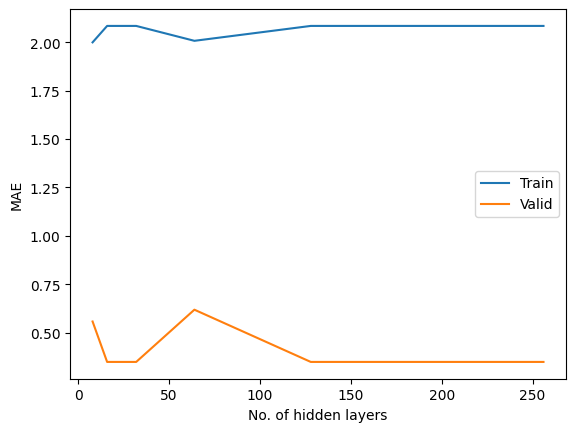

In [24]:
RNN_hidden_layer = [8, 16, 32, 64, 128, 256]
MAE_train = [2.000, 2.085, 2.085, 2.008, 2.085, 2.0850]
MAE_valid = [0.557, 0.348, 0.348, 0.618, 0.348, 0.348]

RMSE_train = [3.418, 3.501, 3.501, 3.420, 3.501, 3.501]
RMSE_valid = [0.603, 0.558, 0.558, 0.658, 0.558, 0.557]

plt.plot(RNN_hidden_layer, MAE_train, label = "Train")
plt.plot(RNN_hidden_layer, MAE_valid, label = "Valid")
plt.legend()
plt.xlabel("No. of hidden layers")
plt.ylabel("MAE")

#

In [59]:
model.evaluate(X_test_tensor, y_test_sequential_tidy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2337 - mae: 0.3099 - root_mean_squared_error: 0.4835


[0.23373733460903168, 0.3099003732204437, 0.4834638833999634]

##### LSTM

In [217]:
model_LSTM = models.Sequential([
    layers.LSTM(units = 8,
                input_shape=(5, 28)),
    layers.Dense(1, activation = "relu")
])


model_LSTM.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)


model_LSTM.fit(
    X_train_tensor,
    y_train_sequential_tidy,
    epochs=100,
    batch_size=16
)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 12.3061 - mae: 2.0507
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.8108 - mae: 2.0076
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.2953 - mae: 1.9771
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.7894 - mae: 1.9603
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.4304 - mae: 1.9831
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.2525 - mae: 2.0003
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.1636 - mae: 2.0093
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10.1082 - mae: 2.0104
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.0728 - mae: 1.9984
Epoch 10/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.0303 - mae: 1.9998
Epoch 11/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 10.0049 - mae: 1.9995
Epoch 12/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.9796 - mae: 1.9829 
Epoch 13/100
45/45 ━━━━━━━━━━━━━━━━━━

In [218]:
model_LSTM.evaluate(X_test_tensor, y_test_sequential_tidy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6.9446 - mae: 2.0281 


[6.944572925567627, 2.0281355381011963]

In [ ]:
 1.8548